In [ ]:
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np
import torchvision.models as models


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



In [56]:
vgg19 = models.vgg19(weights='DEFAULT').eval().to('cuda')
vgg19.features
vgg19.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [42]:
img = Image.open('hr.jpg')
print(img.size)

(2304, 4096)


In [46]:
np.array(img).shape

(4096, 2304, 3)

In [23]:
def transform(res):
    transform_img = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((res, res)),
        transforms.ToTensor()
    ])
    return transform_img

In [24]:
def show_img(lr, hr):
    fig, axes = plt.subplots(1,2, figsize=(8,4))
    axes[0].imshow(lr.permute(1, 2, 0))
    axes[0].set_title('low')
    
    axes[1].imshow(hr.permute(1, 2, 0))
    axes[1].set_title('high')
    
    plt.show()

In [25]:
def get_img(path, res):
    img = np.array(Image.open(path))
    
    return transform(res)(img)

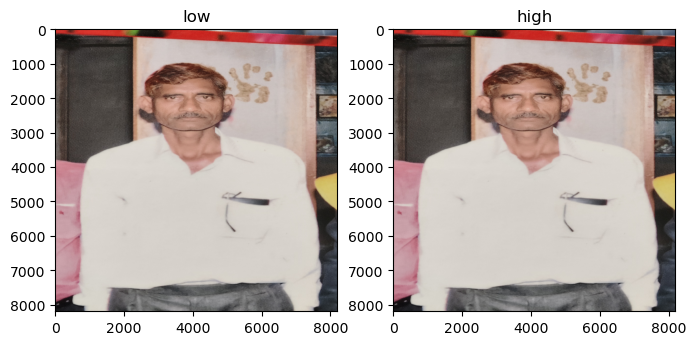

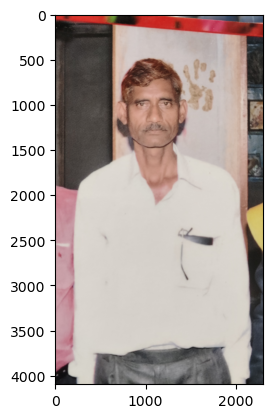

In [ ]:
# i128 = get_img('hr.jpg', 128)
# i256 = get_img('hr.jpg', 256)
# i512 = get_img('hr.jpg', 512)
# i1024 = get_img('hr.jpg', 1024)
# i2048 = get_img('hr.jpg', 2048)
# i4096 = get_img('hr.jpg', 4096)
low = get_img('hr.jpg', 8192)
high = get_img()
# show_img(i128, i256)
# show_img(i512, i1024)
# show_img(i2048, i4096)
show_img(i8192, i8192)
plt.imshow(Image.open('hr.jpg'))